In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [3]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [6]:
from OceanDataStore import OceanDataCatalog

In [13]:
fsose = '/gws/nopw/j04/sid/workspaces/jcocks/data/SOSE/Adelie_138E_150E/Adelie*.nc'

In [15]:
sose = xr.open_mfdataset(glob(fsose))

In [17]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',variable_names=['zos'])

  2025-11-24T16:48:00.097327Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: error trying to connect: HTTP connect timeout occurred after 1s: HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.5.18/src/imds/region.rs:66



In [37]:
sla = SLA(deg=0.25).da

In [26]:
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]
t1 = sose.time[0]
t2 = sla.time[-1]


In [29]:
# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to time
zos = nemo.zos.where(mask,drop=True).sel(time_counter=slice(t1,t2))
# make monthly
zos = zos.resample({'time_counter':'MS'}).mean()
# relative anomaly
zos = zos - zos.mean('time_counter')

In [30]:
zos.load()

<xarray.DataArray 'zos' (time_counter: 107, y: 28, x: 142)> Size: 2MB
array([[[ 0.04730463,  0.04785895,  0.04851723, ...,  0.06590438,
          0.06577361,  0.0656817 ],
        [ 0.04763079,  0.0481261 ,  0.04867232, ...,  0.06647384,
          0.06634557,  0.0662545 ],
        [ 0.04798734,  0.04843915,  0.04890656, ...,  0.06714988,
          0.06699562,  0.06687331],
        ...,
        [ 0.05702806,  0.05673754,  0.05641282, ...,  0.052091  ,
          0.05293143,  0.05392671],
        [ 0.05710471,  0.0569253 ,  0.05668032, ...,  0.04824281,
          0.04930103,  0.05049217],
        [ 0.05721235,  0.05716598,  0.05704319, ...,  0.04429519,
          0.04556096,  0.04694903]],

       [[ 0.04191709,  0.04232812,  0.0427357 , ...,  0.04014075,
          0.0397166 ,  0.03936648],
        [ 0.04206848,  0.04245317,  0.04280353, ...,  0.04144299,
          0.0410111 ,  0.04064858],
        [ 0.04219723,  0.04253268,  0.04280412, ...,  0.04284167,
          0.04242826,  0.04205668],
...
        [-0.0356158 , -0.03620911, -0.0371201 , ..., -0.01254594,
         -0.01361394, -0.01395249],
        [-0.03412783, -0.03475833, -0.03573346, ..., -0.01408339,
         -0.01505721, -0.0151304 ],
        [-0.03264582, -0.03327727, -0.03425789, ..., -0.01635873,
         -0.01727831, -0.01711082]],

       [[-0.06368744, -0.06399548, -0.0645858 , ..., -0.04138052,
         -0.04136825, -0.04138482],
        [-0.06271565, -0.06296611, -0.0634135 , ..., -0.04127634,
         -0.0413934 , -0.04155111],
        [-0.06171787, -0.06189275, -0.06215668, ..., -0.04108787,
         -0.04121339, -0.04138684],
        ...,
        [-0.04393208, -0.04512537, -0.04647326, ..., -0.00087333,
         -0.00238693, -0.0039978 ],
        [-0.04170656, -0.04325473, -0.04507899, ...,  0.00218594,
          0.00083077, -0.00043869],
        [-0.03934824, -0.04116797, -0.04343164, ...,  0.00420475,
          0.00288916,  0.00178003]]], shape=(107, 28, 142), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 856B 2013-01-01 ... 2021-11-01
  * y             (y) int64 224B 978 979 980 981 982 ... 1002 1003 1004 1005
  * x             (x) int64 1kB 782 783 784 785 786 787 ... 919 920 921 922 923
    nav_lat       (y, x) float64 32kB -65.94 -65.94 -65.94 ... -65.01 -65.01
    nav_lon       (y, x) float64 32kB 138.2 138.2 138.3 ... 149.7 149.8 149.9
Attributes:
    standard_name:       sea_surface_height_above_geoid
    long_name:           Sea Surface Height Above Geoid
    units:               m
    online_operation:    average
    interval_operation:  450 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 450 s)

In [38]:
# prepare SLA
# cropto region
sla = Region('AC',extent).crop_da(sla)
# crop to time
sla = sla.sel(time=slice(t1,t2))
# take new mean
sla = sla - sla.mean('time')
# convert to m
sla = sla / 100

In [31]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (sose.SIheff * rho_ice) + (sose.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
etan = (sose.ETAN + sload)

# prepare SOSE
etan = etan.sel(time=slice(t1,t2)).resample({'time':'MS'}).mean()
etan = etan - etan.mean('time')


In [32]:
etan.load()

<xarray.DataArray (time: 107, YC: 15, XC: 72)> Size: 462kB
array([[[-0.15703726, -0.1538806 , -0.15106082, ..., -0.13581228,
         -0.13799345, -0.1392752 ],
        [-0.14906824, -0.14649451, -0.14427817, ..., -0.12653887,
         -0.12956631, -0.13175058],
        [-0.14106035, -0.13915372, -0.13761473, ..., -0.1135062 ,
         -0.11696196, -0.12014627],
        ...,
        [-0.0561707 , -0.0519681 , -0.05082595, ...,  0.04084694,
          0.03917742,  0.03466964],
        [-0.03907752, -0.03537524, -0.03491008, ...,  0.05677736,
          0.05466819,  0.04970515],
        [-0.0274359 , -0.02448916, -0.02480149, ...,  0.07245147,
          0.07023942,  0.06511688]],

       [[-0.15407848, -0.15139139, -0.15002227, ..., -0.13936782,
         -0.14214993, -0.14411438],
        [-0.14857256, -0.14629066, -0.14524984, ..., -0.12573159,
         -0.12896013, -0.13150835],
        [-0.14413214, -0.14258385, -0.14187121, ..., -0.11029327,
         -0.11364102, -0.11664462],
...
        [ 0.07751513,  0.07658947,  0.07678533, ...,  0.07904673,
          0.08332789,  0.08776116],
        [ 0.07008278,  0.06938541,  0.07023358, ...,  0.07070386,
          0.07614219,  0.08202565],
        [ 0.06445432,  0.06428599,  0.06571376, ...,  0.06139982,
          0.06707072,  0.07374537]],

       [[-0.01240671, -0.00914562, -0.00664485, ..., -0.01380396,
         -0.01273441, -0.01302624],
        [-0.01199257, -0.00938284, -0.00706053, ..., -0.01585305,
         -0.01381099, -0.01402044],
        [-0.0134877 , -0.01155734, -0.00920129, ..., -0.01776588,
         -0.01541328, -0.01526928],
        ...,
        [-0.03332317, -0.03400528, -0.03422737, ..., -0.04533505,
         -0.04276431, -0.04053319],
        [-0.03726709, -0.03759038, -0.03733158, ..., -0.0530144 ,
         -0.04989946, -0.04678214],
        [-0.0413028 , -0.04082406, -0.0400573 , ..., -0.05895162,
         -0.05704415, -0.0539968 ]]], shape=(107, 15, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 856B 2013-01-01 2013-02-01 ... 2021-11-01
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
    rA       (YC, XC) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    Depth    (YC, XC) float64 9kB 900.0 950.0 950.0 ... 3.32e+03 3.32e+03
Attributes:
    standard_name:  ETAN
    long_name:      Surface Height Anomaly
    units:          m

In [40]:
etanav = etan.mean(['XC','YC'])
zosav = zos.mean(['x','y'])
slaav = sla.mean(['latitude','longitude'])

Text(0, 0.5, 'sla (cm)')

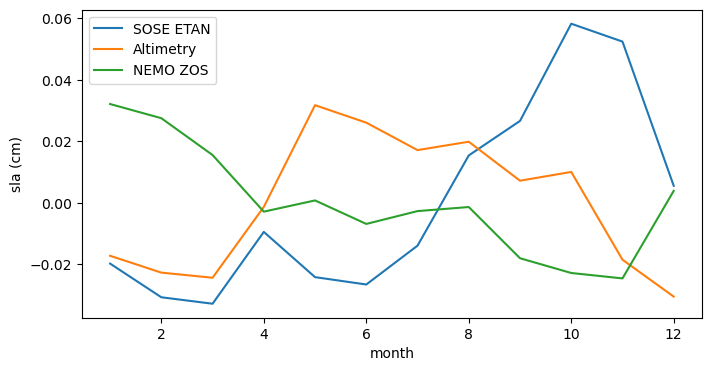

In [ ]:
# compare climatologies
fig,ax = plt.subplots(figsize=(8,4))
soseclim=etanav.groupby('time.month').mean()
alticlim=slaav.groupby('time.month').mean()
nemoclim=zosav.groupby('time_counter.month').mean()

ax.plot(soseclim.month,soseclim,label='SOSE ETAN')
ax.plot(alticlim.month,alticlim,label='Altimetry')
ax.plot(nemoclim.month,nemoclim,label='NEMO ZOS')

ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')


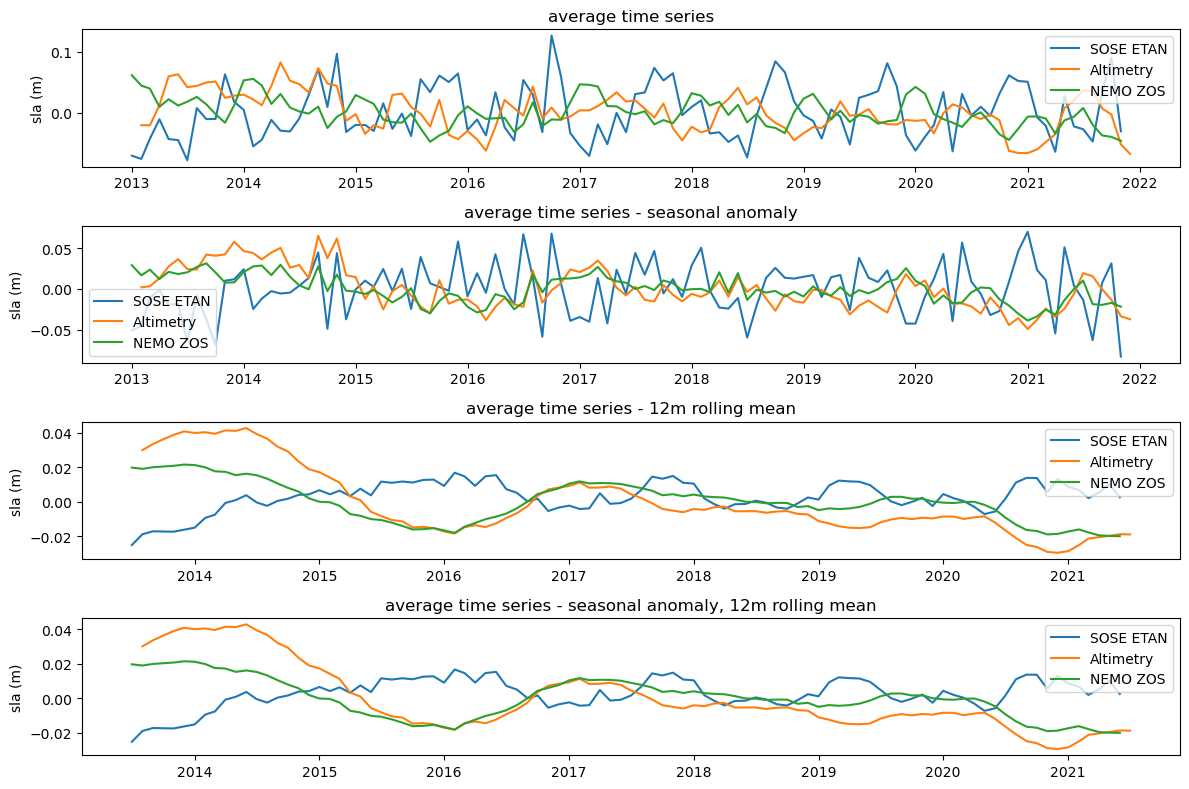

In [47]:
# compare time series
fig,axs = plt.subplots(4,1,figsize=(12,8))

# 1 - straightforward timeseries
ax=axs[0]
ax.plot(etan.time,etanav,label='SOSE ETAN')
ax.plot(sla.time,slaav,label='Altimetry')
ax.plot(zos.time_counter,zosav,label='NEMO ZOS')
ax.set_title('average time series')

ax.legend()
ax.set_ylabel('sla (m)')


# 2 - seasonal anomaly
ax=axs[1]
ax.plot(etan.time,etanav.groupby('time.month') - soseclim,label='SOSE ETAN')
ax.plot(sla.time,slaav.groupby('time.month') - alticlim,label='Altimetry')
ax.plot(zos.time_counter,zosav.groupby('time_counter.month') - nemoclim,label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly')

ax.legend()
ax.set_ylabel('sla (m)')

# 3 - rolling timeseries
ax=axs[2]
ax.plot(etan.time,etanav.rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,slaav.rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,zosav.rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')

# 4 - rolling timeseries
ax=axs[3]
ax.plot(etan.time,(etanav.groupby('time.month') - soseclim).rolling({'time':12},center=True).mean(),label='SOSE ETAN')
ax.plot(sla.time,(slaav.groupby('time.month') - alticlim).rolling({'time':12},center=True).mean(),label='Altimetry')
ax.plot(zos.time_counter,(zosav.groupby('time_counter.month') - nemoclim).rolling({'time_counter':12},center=True).mean(),label='NEMO ZOS')
ax.set_title('average time series - seasonal anomaly, 12m rolling mean')

ax.legend()
ax.set_ylabel('sla (m)')

plt.tight_layout()